# IMDb Movies Analysis

Karolina Szczepanik
ECO 590

# Motivation

IMDb ratings play an important role in how audiences evaluate films. This project explores whether movie characteristics such as runtime, awards count, and genre count are associated with IMDb ratings. Using data collected from the OMDb API, the project analyzes patterns between film characteristics and audience ratings.


# Research Question

1. Does runtime have a relationship with IMDb ratings?

2. Do awards count and genre count affect IMDb ratings?

3. Which movie characteristic appears to have the strongest relationship with IMDb ratings?

# Part 1: Collecting Movie Data from the OMDb API

For this project, I collected movie data using the OMDb API, which stands for The Open Movie Database. I first created a list of 100 movie titles that I wanted to analyze. Then I used my OMDb API key to send a request for each movie title.

The API request was built using the movie title and my API key:

`http://www.omdbapi.com/?t={movie}&apikey={api_key}`

For each movie in my list, Python sent the request, received the movie information in JSON format, and saved only the valid responses. After collecting the results, I turned the data into a pandas dataframe so I could clean it and use it for graphs and regression analysis.

In [1]:
import requests

api_key = "d9eea423"

movie = "Interstellar"

#test API to see what the data looks like 
url = f"http://www.omdbapi.com/?t={movie}&apikey={api_key}"

response = requests.get(url)
data = response.json()

print(data)

{'Title': 'Interstellar', 'Year': '2014', 'Rated': 'PG-13', 'Released': '07 Nov 2014', 'Runtime': '169 min', 'Genre': 'Adventure, Drama, Sci-Fi', 'Director': 'Christopher Nolan', 'Writer': 'Jonathan Nolan, Christopher Nolan', 'Actors': 'Matthew McConaughey, Anne Hathaway, Jessica Chastain', 'Plot': 'When Earth becomes uninhabitable in the future, a farmer and ex-NASA pilot, Joseph Cooper, is tasked to pilot a spacecraft, along with a team of researchers, to find a new planet for humans.', 'Language': 'English', 'Country': 'United States, United Kingdom, Canada', 'Awards': 'Won 1 Oscar. 45 wins & 148 nominations total', 'Poster': 'https://m.media-amazon.com/images/M/MV5BYzdjMDAxZGItMjI2My00ODA1LTlkNzItOWFjMDU5ZDJlYWY3XkEyXkFqcGc@._V1_QL75_UX380_CR0,0,380,562_.jpg', 'Ratings': [{'Source': 'Internet Movie Database', 'Value': '8.7/10'}, {'Source': 'Rotten Tomatoes', 'Value': '73%'}, {'Source': 'Metacritic', 'Value': '74/100'}], 'Metascore': '74', 'imdbRating': '8.7', 'imdbVotes': '2,516,75

In [2]:
import requests
import pandas as pd

api_key = "d9eea423"

movies = [
    "The Godfather",
    "Casablanca",
    "Citizen Kane",
    "Gone with the Wind",
    "Lawrence of Arabia",
    "The Wizard of Oz",
    "The Graduate",
    "On the Waterfront",
    "Schindler's List",
    "Singin' in the Rain",
    "It's a Wonderful Life",
    "Sunset Boulevard",
    "The Bridge on the River Kwai",
    "Some Like It Hot",
    "Star Wars",
    "All About Eve",
    "The African Queen",
    "Psycho",
    "Chinatown",
    "One Flew Over the Cuckoo's Nest",
    "The Grapes of Wrath",
    "2001: A Space Odyssey",
    "The Maltese Falcon",
    "Raging Bull",
    "E.T.",
    "Dr. Strangelove",
    "Bonnie and Clyde",
    "Apocalypse Now",
    "Mr. Smith Goes to Washington",
    "Treasure of the Sierra Madre",
    "Annie Hall",
    "The Godfather Part II",
    "High Noon",
    "To Kill a Mockingbird",
    "Rocky",
    "The Silence of the Lambs",
    "Network",
    "The Manchurian Candidate",
    "American Graffiti",
    "Raiders of the Lost Ark",
    "Vertigo",
    "Tootsie",
    "Stagecoach",
    "Close Encounters of the Third Kind",
    "The Philadelphia Story",
    "Shane",
    "It Happened One Night",
    "A Streetcar Named Desire",
    "Rear Window",
    "Forrest Gump",
    "The Shawshank Redemption",
    "Fight Club",
    "Interstellar",
    "The Matrix",
    "Pulp Fiction",
    "Goodfellas",
    "The Dark Knight",
    "Whiplash",
    "Parasite",
    "Joker",
    "Black Swan",
    "The Pianist",
    "The Green Mile",
    "Gladiator",
    "Memento",
    "The Prestige",
    "The Departed",
    "No Country for Old Men",
    "Arrival",
    "Blade Runner 2049",
    "Dune",
    "Oppenheimer",
    "Barbie",
    "Lady Bird",
    "Little Women",
    "The Notebook",
    "Manchester by the Sea",
    "Good Will Hunting",
    "Toy Story",
    "Coco",
    "Up",
    "Finding Nemo",
    "Wall-E",
    "Spirited Away",
    "Your Name",
    "City of God",
    "Seven Samurai",
    "Oldboy",
    "The Handmaiden",
    "Life Is Beautiful",
    "Pan's Labyrinth",
    "Roma",
    "Moonlight",
    "Minari",
    "Past Lives",
    "Portrait of a Lady on Fire",
    "Amélie",
    "The Florida Project",
    "Call Me by Your Name",
    "The Truman Show"
    ]
    
movie_data = []

#loop through each movie and get data from the API
for movie in movies:
    url = f"http://www.omdbapi.com/?t={movie}&apikey={api_key}"
    response = requests.get(url)
    data = response.json()

    #only keep valid responses
    if data["Response"] == "True":
        movie_data.append(data)

# turn everything into a dataframe
df = pd.DataFrame(movie_data)

#check
df

# I also tried using BeautifulSoup to scrape movie titles directly from an IMDb list page.
# The request connected successfully, but IMDb did not return the movie titles in a way that BeautifulSoup could easily extract.
# Because of that, I continued using the manually created list of 100 movie titles so the dataset would stay complete and consistent.

,Title,Year,Rated,Released,Runtime,Genre,Director,Writer,Actors,Plot,...,Metascore,imdbRating,imdbVotes,imdbID,Type,DVD,BoxOffice,Production,Website,Response
0,The Godfather,1972,R,24 Mar 1972,175 min,"Crime, Drama",Francis Ford Coppola,"Mario Puzo, Francis Ford Coppola","Marlon Brando, Al Pacino, James Caan",The aging patriarch of an organized crime dyna...,...,100,9.2,"2,222,804",tt0068646,movie,N/A,"$136,381,073",N/A,N/A,True
1,Casablanca,1943,PG,23 Jan 1943,102 min,"Drama, Romance, War",Michael Curtiz,"Philip G. Epstein, Julius J. Epstein, Howard Koch","Humphrey Bogart, Ingrid Bergman, Paul Henreid",A cynical expatriate American cafe owner strug...,...,100,8.5,"654,681",tt0034583,movie,N/A,"$4,219,709",N/A,N/A,True
2,Citizen Kane,1941,PG,05 Sep 1941,119 min,"Drama, Mystery",Orson Welles,"Herman J. Mankiewicz, Orson Welles, Roger Q. D...","Orson Welles, Joseph Cotten, Dorothy Comingore",Following the death of publishing tycoon Charl...,...,100,8.2,"491,492",tt0033467,movie,N/A,"$1,627,530",N/A,N/A,True
3,Gone with the Wind,1939,G,17 Jan 1940,238 min,"Drama, Romance, War",Victor Fleming,"Margaret Mitchell, Sidney Howard, Oliver H.P. ...","Clark Gable, Vivien Leigh, Thomas Mitchell",A sheltered and manipulative Southern belle an...,...,97,8.2,"354,268",tt0031381,movie,N/A,"$200,882,193",N/A,N/A,True
4,Lawrence of Arabia,1962,PG,02 Apr 2013,227 min,"Adventure, Biography, Drama",David Lean,"Robert Bolt, Michael Wilson","Peter O'Toole, Alec Guinness, Anthony Quinn","The story of T.E. Lawrence, the English office...",...,100,8.3,"334,419",tt0056172,movie,N/A,"$45,306,425",N/A,N/A,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Portrait of a Lady on Fire,2020,R,14 Feb 2020,122 min,"Drama, Romance",Céline Sciamma,Céline Sciamma,"Noémie Merlant, Adèle Haenel, Luàna Bajrami",On an isolated island in Brittany at the end o...,...,95,8.0,"126,866",tt8613070,movie,N/A,"$3,759,854",N/A,N/A,True
96,Amélie,2002,R,08 Feb 2002,122 min,"Comedy, Romance",Jean-Pierre Jeunet,"Guillaume Laurant, Jean-Pierre Jeunet","Audrey Tautou, Mathieu Kassovitz, Rufus","Despite being caught in her imaginative world,...",...,70,8.3,"839,094",tt0211915,movie,N/A,"$33,712,444",N/A,N/A,True
97,The Florida Project,2017,R,10 Nov 2017,111 min,Drama,Sean Baker,"Sean Baker, Chris Bergoch","Brooklynn Prince, Bria Vinaite, Willem Dafoe",A single mother and the manager of a roadside ...,...,92,7.6,"141,797",tt5649144,movie,N/A,"$5,904,366",N/A,N/A,True
98,Call Me by Your Name,2017,R,19 Jan 2018,132 min,"Drama, Romance",Luca Guadagnino,"James Ivory, André Aciman","Timothée Chalamet, Armie Hammer, Michael Stuhl...","In the summer of 1983, 17-year-old Elio is spe...",...,94,7.8,"351,228",tt5726616,movie,N/A,"$18,095,701",N/A,N/A,True


# Part 2: Cleaning and Creating New Variables

After collecting the API data, I cleaned the variables so they could be used in analysis. IMDb rating and runtime were originally stored as text, so I converted them into numeric values. I also created two new variables: Awards_Count and Genre_Count. Awards_Count adds together the numbers found in the awards text, and Genre_Count counts how many genres are listed for each movie.

In [28]:
# remove rows where IMDb rating is missing ("N/A")
df = df[df["imdbRating"] != "N/A"].copy()

# remove rows where runtime is missing ("N/A")
df = df[df["Runtime"] != "N/A"].copy()

# convert IMDb rating into float
df["imdbRating"] = df["imdbRating"].astype(float)

# turn Runtime column into string format first
# needed so .str.replace() can work properly
# clean runtime only if it still has "min"
df["Runtime"] = df["Runtime"].astype(str)
df["Runtime"] = df["Runtime"].str.replace(" min", "")

# convert runtime into float
df["Runtime"] = df["Runtime"].astype(float)

df[["imdbRating", "Runtime"]].head()

# I originally used errors="coerce" with pd.to_numeric()
# but changed the code to astype(float) to match the method shown in class
# I also had to remove "N/A" values first to avoid conversion errors

,imdbRating,Runtime
0,9.2,175.0
1,8.5,102.0
2,8.2,119.0
3,8.2,238.0
4,8.3,227.0


# Part 3: Exploring the Relationship Between Movie Characteristics and IMDb Ratings

After cleaning the dataset and creating new variables, I explored how different movie characteristics relate to IMDb ratings. I created graphs to visualize patterns in the data, including the relationship between awards count, runtime, and IMDb ratings. I also examined the overall distribution of IMDb ratings across the dataset.

Next, I used regression models to test whether variables such as runtime, awards count, and genre count are associated with higher IMDb ratings. I compared multiple models, including one focused only on movies longer than 120 minutes, to see whether the relationships changed across different subsets of films.

References:
https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.fillna.html


In [30]:
# create Awards_Count by extracting numbers from the Awards column
#.fillna(0) replaces missing values with 0
df["Awards_Count"] = df["Awards"].str.extract(r'(\d+)').fillna(0).astype(int)

# create Genre_Count column
df["Genre_Count"] = df["Genre"].str.split(",").apply(len)

df[["Awards_Count", "Genre_Count"]].head()

,Awards_Count,Genre_Count
0,3,2
1,3,3
2,1,2
3,8,3
4,7,3


# Part 4: Graphs and Visualizations

After creating the new variables, I made graphs to see how awards count and genre count relate to IMDb ratings. I also created a density curve to show where most IMDb ratings fall in the dataset.

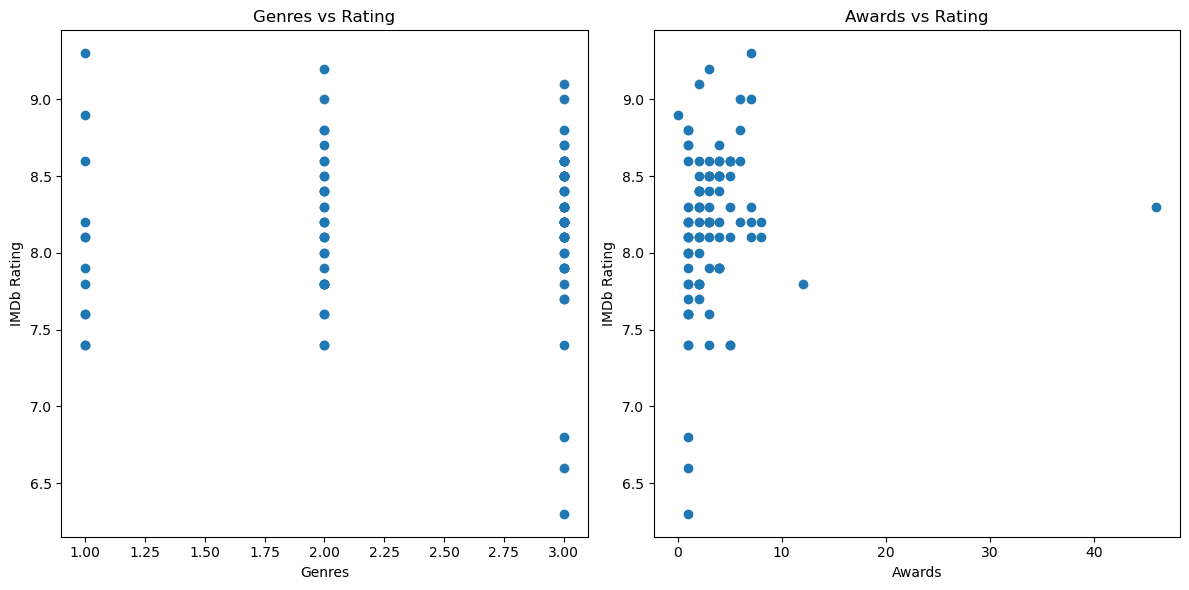

In [31]:
#import graphing library
import matplotlib.pyplot as plt

# create Genre_Count variable (counts how many genres are listed for each movie)
df["Genre_Count"] = df["Genre"].apply(lambda x: len(x.split(",")))

# create a figure that will hold 2 graphs side by side
plt.figure(figsize=(12,6))

# GRAPH 1

# placing first graph in position 1
plt.subplot(1,2,1)

# scatterplot comparing genre count and IMDb rating
plt.scatter(df["Genre_Count"], df["imdbRating"])

# label x-axis
plt.xlabel("Genres")

# label y-axis
plt.ylabel("IMDb Rating")

# title of graph
plt.title("Genres vs Rating")

# GRAPH 2

# placing second graph in position 2
plt.subplot(1,2,2)

# scatterplot comparing awards count and IMDb rating
plt.scatter(df["Awards_Count"], df["imdbRating"])

# label x-axis
plt.xlabel("Awards")

# label y-axis
plt.ylabel("IMDb Rating")

# title of graph
plt.title("Awards vs Rating")

# automatically spaces graphs nicely
plt.tight_layout()

plt.show()

## Interpretation of the Graphs

Genres vs IMDb Rating:

This scatterplot compares the number of genres each movie had with its IMDb rating. Movies with more genres did not consistently receive higher ratings, suggesting only a weak relationship between genre count and IMDb ratings.

    
Awards vs IMDb Rating:

This graph shows the relationship between awards count and IMDb ratings. Movies with a higher number of awards generally tended to have slightly higher ratings, although the relationship was not very strong and there were several outliers in the dataset.

# Part 5: Regression Analysis

After visualizing the relationships in the graphs, I used regression analysis to examine the relationships more directly. IMDb rating was used as the dependent variable, while runtime, awards count, and genre count were used as independent variables.

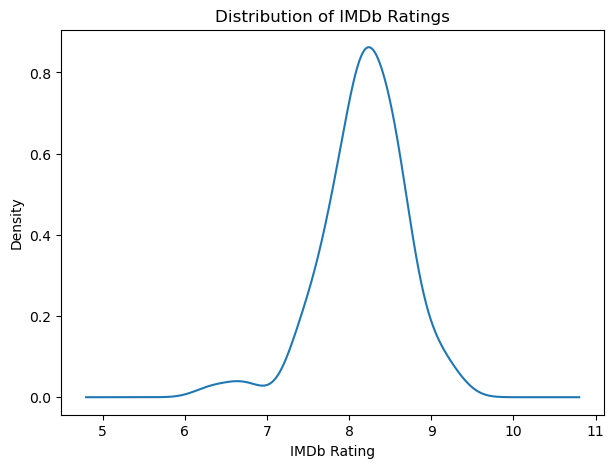

In [32]:
# create figure size
plt.figure(figsize=(7,5))

# create density curve for IMDb ratings (shows where ratings are most concentrated)
df["imdbRating"].plot(kind="density")

# graph title
plt.title("Distribution of IMDb Ratings")

# x label
plt.xlabel("IMDb Rating")
# ylabel
plt.ylabel("Density")


plt.show()

## Graph Interpretation
This density curve shows the overall distribution of IMDb ratings in the dataset. Most ratings are concentrated around the 8.0–8.5 range, suggesting that many of the selected films are highly rated movies. Very low or extremely high ratings were less common, creating a strong peak near the center of the distribution.

# Conclusion

This project explored how movie characteristics such as runtime, awards count, and genre count relate to IMDb ratings using data collected from the OMDb API. The visualizations and regression analysis suggested that awards count appeared to have the strongest relationship with IMDb ratings, while genre count appeared to have a weaker relationship.

Working on this project also helped me better understand the process of collecting API data, cleaning variables in Python, creating visualizations, and running regression models to analyze relationships in a dataset.